In [1]:
import matplotlib.pyplot as plt
import numpy as np
import flopy
import scipy
from subprocess import Popen, PIPE
import os
import pandas as pd
import glob
import subprocess
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import shutil
import matplotlib.cm as cm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [172]:
nlay = 3
nrow_inner = 350
ncol_inner = 350
dx = 1.0 #1 meter finer cell size
dy = dx
dx_outer = [1.5 ** i for i in range(1, 20)]
dy_outer = dx_outer
delr = dx_outer[::-1] + ncol_inner * [dx] + dx_outer
delc = dy_outer[::-1] + nrow_inner * [dy] + dy_outer
delr = np.array(delr)
delc = np.array(delc)
nrow = delc.shape[0]
ncol = delr.shape[0]
top = 0. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [-14. * 0.3048, -16. * 0.3048, -30. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]

#create a flopy grid object
model_grid = flopy.discretization.StructuredGrid(
    delr=delr, 
    delc=delc, 
    top=top, 
    botm=botm
)

In [173]:
#aquifer_thickness = top[0, 0] - botm[0, 0, 0]
specific_storage = 1.e-5
#storage_coefficient = specific_storage * aquifer_thickness
initial_homo_k = 6

In [174]:
specific_storage = [1.e-5, 1.e-5, 1.e-5]

# Go through each layer, and calculate and print
# layer information
for k in range(nlay):
    print(f"\nProcessing Layer {k}")
    if k == 0:
        aquifer_thickness = top[0, 0] - botm[0, 0, 0]
    else:
        aquifer_thickness = botm[k - 1, 0, 0] - botm[k, 0, 0]

    print(f"{aquifer_thickness=:.2f} m")
    #print(f"{hydraulic_conductivity[k]=:.2f} m/day")
    print(f"{specific_storage[k]=:.2e} 1/m")
    #transmissivity = hydraulic_conductivity[k] * aquifer_thickness
    #print(f"{transmissivity=:.2f} m/day")
    storage_coefficient = specific_storage[k] * aquifer_thickness
    print(f"{storage_coefficient=:.2e}")


Processing Layer 0
aquifer_thickness=4.27 m
specific_storage[k]=1.00e-05 1/m
storage_coefficient=4.27e-05

Processing Layer 1
aquifer_thickness=0.61 m
specific_storage[k]=1.00e-05 1/m
storage_coefficient=6.10e-06

Processing Layer 2
aquifer_thickness=4.27 m
specific_storage[k]=1.00e-05 1/m
storage_coefficient=4.27e-05


Loading well coords, max buildup for each well and test, and MLAC center coords

In [175]:
df = pd.read_csv("../data/wells_data.csv", index_col=0)
wells = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')
MLAC_center = df.loc['MLAC_center'].tolist()

Setting up the MODFLOW grid coords to match field coords.

Centering the MODFLOW grid on the MLAC center.


In [176]:
grid_length_x = delr.sum()
grid_length_y = delc.sum()
xoff = MLAC_center[0] - 0.5 * grid_length_x
yoff = MLAC_center[1] - 0.5 * grid_length_y
model_grid.set_coord_info(xoff=xoff, yoff=yoff)

Loading injection test information from the field for reproducing in the simulation

In [177]:
df = pd.read_csv('../data/injection_tests_data.csv', index_col=0)
injection_tests = df.to_dict(orient='index')

#changing the initial K values
for test in injection_tests: 
    injection_tests[test]['K_guess'] = initial_homo_k

Running the simulations

In [239]:
#RUNNING MODELS

#to obtain all the injection tests IDs
injected_well_IDs = [i for i in injection_tests]  

#to obtain all the coords of the injected wells
injected_wells_coords = {i["inj_well"]: wells[i["inj_well"]] for i in injection_tests.values()}  
gwf_list = {}


count = 0
for inj_ID in injected_well_IDs:
    ws = f'../results/3d_injection_modeling_{injection_tests[inj_ID]["inj_well"]}'
    name = 'MLAC-model'
    if inj_ID != "24inj08": 
        continue
    
    try:
        os.mkdir(ws)
    except FileExistsError:
        pass


    # create simulation object
    sim = flopy.mf6.MFSimulation(sim_name=name, sim_ws=ws, exe_name='mf6')

    # set up time stepping - TDIS package - Temporal Discretization
    perlen = injection_tests[inj_ID]["inj_duration"] #length of the stress period
    nstp = 50 #number of time steps in the stress period
    tsmult = 1.2 #multiplier for the length of sucessive time steps
    perioddata = 1 * [(perlen, nstp, tsmult)]
    nper = len(perioddata)
    tdis = flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=perioddata)

    '''
    The length of a time step is calculated by multiplying the length of the previous time step by TSMULT.
    The length of the first time step, Delta_t1, is related to PERLEN, NSTP, nad TSMULT by the relation 
    Delta_t2 = PERLEN * [(TSMULT - 1) / (TSMULT^NSTP - 1)]

    '''

    # solver - IMS package - Interactive Model Solution (IMS) - this will solve all the models added to it.
    ims = flopy.mf6.ModflowIms(
        sim, #simalution where the IMS package will be added
        inner_dvclose=0.0001,  # real value defining the dependent-variable (e.g. head) change criterion for convergence of the inner (linear) iterations - when the maximum aboslute value of the dependent-variable change at all nodes during an iteration is less than or equal to INNER_DVCLOSE, the matrix solver assumes convergence
        outer_dvclose=0.0001 # Commonly, OUTER_DVCLOSE equals 0.01. Commonly, INNER_DVCLOSE is set an order of magnitude less than the OUTER_DVCLOSE value specified for the NONLINEAR block.
    )

    # groundwater flow model - defining GWF model - Groundwater Flow model 
    gwf = flopy.mf6.ModflowGwf(
        sim, #simalution to add the GWF package
        modelname=name, #
        save_flows=True, #keyowrk to indicate that all model package flow terms will be written to the file specified with "BUDGET FILEOUT" in Output Control
    )

    # create the discretization - defining a DIS package within a gwf6 model - Structured Discretization (DIS) - discretization information for structured grids

    dis = flopy.mf6.ModflowGwfdis(
        gwf, #groundwater flow model
        nlay=nlay, #number of layers in the model grid
        nrow=nrow, #number of rows in the model grid
        ncol=ncol, #number of columns in the model grid
        delr=delr, #column spacing in the row direction
        delc=delc, #row spacing in the column direction
        top=top, #top elevation on the top model layer
        botm=botm_dis, #bottom elevation for each layer
        xorigin=xoff, #x-position of the lower-left corner of the model grid
        yorigin=yoff #y-position of the lower-left corner of the model grid
    )

    # initial conditions - defining IC package within gwf6 model - Initial Conditions (IC) Package
    strt = top.max() * np.ones((nlay, nrow, ncol)) #initial head matching the top elevation value 
    ic = flopy.mf6.ModflowGwfic(gwf, 
                                strt=strt #(zero initial head all domain)
                                )

    # Node Property Flow (NPF) package - 
    #hydraulic_conductivity = injection_tests[inj_ID]["K_guess"]
    #kh_field = np.ones((nlay, nrow, ncol))*hydraulic_conductivity  # uniform K field
    #kv_field = np.ones((nlay, nrow, ncol))*hydraulic_conductivity  #kh == kv

    #kh_field = np.random.lognormal(mean=np.log(hydraulic_conductivity), sigma=1.0, size=(nlay, nrow, ncol)) #random K field
    #kv_field = np.random.lognormal(mean=np.log(hydraulic_conductivity), sigma=1.0, size=(nlay, nrow, ncol))
    
    #hk = np.loadtxt(f'./hk.ref')
    
    
    hk = [5, 20, 5] #hk for each layer
    npf = flopy.mf6.ModflowGwfnpf(
        gwf, 
        k=hk,  # horizontal k 
        k33=hk,  # vertical k 
        #k33=[0.001, 0.001, 0.001] #testing vertical anisotropy
    )


    # Storage Package (STO)

    sto = flopy.mf6.ModflowGwfsto(
        gwf, 
        ss=specific_storage,
    )

    # Constant Head (CHD) package
    # place constant heads around grid perimeter
    ibd = np.ones((nlay, nrow, ncol), dtype=int)
    ibd[:, 1:-1, 1:-1] = 0

    #excluding cells for simulating packer above and below BPP for inj location
    pump_ij = model_grid.intersect(wells[injection_tests[inj_ID]["inj_well"]]['Easting'], 
                                   wells[injection_tests[inj_ID]["inj_well"]]['Northing']) #obtaing the grid info for the injection location by given the well coords
    #ibd[0, pump_ij[0], pump_ij[1]] = -1 #think about inactivating cells where packer were placed
    #ibd[2, pump_ij[0], pump_ij[1]] = -1 ##think about inactivating cells where packer were placed, this looked like not worked
    well_ids = [(wells[well]['Easting'], 
                 wells[well]['Northing']) 
                 for well in wells]
    
    #for well in well_ids: 
        #i, j = model_grid.intersect(well[0], well[1])
        #ibd[0, i, j] = 0
        #ibd[2, i, j] = 0


    idx = np.where(ibd == 1)
    spd = [(k, i, j, strt[k, i, j]) for k, i, j in zip(*idx)]
    chd = flopy.mf6.ModflowGwfchd(
        gwf, 
        stress_period_data=spd, #stre
    )

    # well package (WEL) - 
    spd = {0: [[(1, pump_ij[0], pump_ij[1]), -injection_tests[inj_ID]["inj_rate"]]], 1:[]} #pumping at BPP layer
    wel = flopy.mf6.ModflowGwfwel(
        gwf, 
        stress_period_data=spd,
        print_input=True, #new
        print_flows=True #new
    )

    # output control (OC) package
    budget_file = name + '.bud'
    head_file = name + '.hds'
    oc = flopy.mf6.ModflowGwfoc(gwf,
                                budget_filerecord=budget_file,
                                head_filerecord=head_file,
                                headprintrecord=[('COLUMNS', 10, 'WIDTH', 15, 'DIGITS', 6, 'GENERAL')], #NEW
                                saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')], 
                                printrecord=[('HEAD', 'FIRST'), ('HEAD', 'LAST'), ('BUDGET', 'LAST')] #NEW
                                )
    
    # write input files
    sim.write_simulation()
    
    #saving gwf variable for each injection test
    #gwf_list[injection_tests[inj_ID]["inj_well"]] = gwf

    # run the simulation
    sim.run_simulation()

    ################################################################################################################################
    # read the heads and calculate drawdown
    head_obj = gwf.output.head()
    head = head_obj.get_alldata()
    drawdown = head - gwf.ic.strt.array

    # DATA STORING
    #creating a dictionary to collect the data
    data = dict()
    for well in wells:
        idx = []
        i, j = model_grid.intersect(wells[well]['Easting'], wells[well]['Northing'])
        idx.append((1, i, j)) #before was (0, i, j)
        time_series = head_obj.get_ts(idx)

        i, j = model_grid.intersect(wells[well]['Easting'], wells[well]['Northing'])
        t = top[i, j]

        time_buildup = time_series[:, 0] * 1440
        head_buildup = time_series[:, 1] - t

        data[well] = [time_buildup, head_buildup]

    #saving data
    for key, value in data.items():
        df = pd.DataFrame({
            'time_days': value[0],  
            'buildup_meters': value[1]   
        })
        try:
            os.mkdir(ws + '/simulated_data')
        except FileExistsError:
            pass
        df.to_csv(ws + f'/simulated_data/{key}.csv', index=False)




'''
    
    #saving parameters and metrics
    #shutil.copy("./hk.ref", f"{ws}/params_metrics/hk.ref") #saving hk field
    #STEP 6 - Simulation time linkage
    w = injection_tests[inj_ID]['inj_well']
    date = injection_tests[inj_ID]['date']
    start_time = injection_tests[inj_ID]['start_time']
    mod2obs_dbl_inputs = ['../results/MLAC-model.spc', 
                            '../results/wells.crd', 
                            '../results/wells.crd', 
                            f'../results/{w}_observ.smp', 
                            f'../results/injection_modeling_{w}/{w}_observ.smp', 
                            f'../results/injection_modeling_{w}/MLAC-model.hds', 
                            'f', 
                            '1e30', 
                            'd', 
                            f'{date}', 
                            f'{start_time}', 
                            f'{nlay}', 
                            '3', 
                            f'../results/{w}_model.smp'
                            ]

    process = Popen('./mod2obs_dbl.exe', stdin=PIPE, stdout=PIPE)
    for entry in mod2obs_dbl_inputs:
        process.stdin.write((entry + '\n').encode())
    process.stdin.close()
    process.wait()
    print(process.stdout.read().decode())
    #plotting the sim vs. obs
    well = w

    obs_data = pd.read_csv(f'../results/{well}_observ.smp', sep='\s+', header=None)
    sim_data = pd.read_csv(f'../results/{well}_model.smp', sep='\s+', header=None)
    inj_obs_data = pd.read_csv(f'../results/{well}_inj_observ.smp', sep='\s+', header=None)
    inj_sim_data = pd.read_csv(f'../results/{well}_inj_model.smp', sep='\s+', header=None)


    well_names = obs_data[0].unique()
    obs_values = obs_data[3].values
    sim_values = sim_data[3].values
    inj_obs_values = inj_obs_data[3].values
    inj_sim_values = inj_sim_data[3].values

    # Create a figure and axis for the main plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Create a separate figure and axis for the isolated plot
    fig_iso, ax_iso = plt.subplots(figsize=(8, 6))

    # Get the max and min value excluding the well that is plotting (well)
    obs_values_excluding_injwell = obs_values[obs_data[0] != f'{well}']
    sim_values_excluding_injwell = sim_values[sim_data[0] != f'{well}']
    min_val = np.min([np.min(obs_values_excluding_injwell), np.min(sim_values_excluding_injwell)])
    max_val = np.max([np.max(obs_values_excluding_injwell), np.max(sim_values_excluding_injwell)])

    num_wells = len(well_names)
    cmap = cm.get_cmap('jet')
    colors = [cmap(i) for i in np.linspace(0, 1, num_wells+1)]

    well_names = np.append(well_names, injection_tests[inj_ID]["inj_well"])

    for i, well_name in enumerate(well_names):
        well_obs_values = obs_values[obs_data[0] == well_name]
        well_sim_values = sim_values[sim_data[0] == well_name]
        
        # Check if the well name matches the file name
        if well_name == f'{well}':
            # Plot the data on the isolated plot
            ax_iso.scatter(inj_obs_values, inj_sim_values, label=well_name, marker='o', color=colors[i])
            ax_iso.set_title(f'Observation vs Simulation for {well}: k={hk[0]}')
            ax_iso.set_xlabel('Observation')
            ax_iso.set_ylabel('Simulation')
            min_val_iso = np.min([np.min(inj_obs_values), np.min(inj_sim_values)])
            max_val_iso = np.max([np.max(inj_obs_values), np.max(inj_sim_values)])
            ax_iso.plot([min_val_iso, max_val_iso], [min_val_iso, max_val_iso], color='grey', linestyle='--')
            ax_iso.legend()
            ax_iso.figure.savefig(f"{ws}/params_metrics/{well}_obs_vs_sim_injection_plot.png")

        elif well_name != f'{well}':
            # Plot the data on the main plot
            ax.scatter(well_obs_values, well_sim_values, label=well_name, marker='o', color=colors[i])
            ax.plot([min_val, max_val], [min_val, max_val], color='grey', linestyle='-')          
            ax.set_title(f'Observation vs Simulation besides injected well ({well}): k={hk[0]}')
            ax.set_xlabel('Observation')
            ax.set_ylabel('Simulation')
            ax.legend()
            ax.figure.savefig(f"{ws}/params_metrics/{well}_obs_vs_sim_observations_plot.png")
    
        

    plt.show()

    def calculate_errors(file1, file2):
        df1 = pd.read_csv(file1, sep=r'\s+', header=None)
        df2 = pd.read_csv(file2, sep=r'\s+', header=None)
        y_pred = df1.iloc[:, 3]
        y_true = df2.iloc[:, 3]
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2

    # Load the data from the two files
    files = glob.glob(f'../results/{well}*.smp')
    obs_data = pd.read_csv(files[3], sep='\s+', header=None)
    sim_data = pd.read_csv(files[2], sep='\s+', header=None)

    # Get the unique well names
    well_names = obs_data[0].unique()

    # Create a dictionary to store the results
    results = {}

    for well_name in well_names:
        # Filter the data for the current well
        obs_well_data = obs_data[obs_data[0] == well_name]
        sim_well_data = sim_data[sim_data[0] == well_name]
        
        # Calculate the MAE, RMSE, and R2
        mae = mean_absolute_error(obs_well_data[3], sim_well_data[3])
        rmse = np.sqrt(mean_squared_error(obs_well_data[3], sim_well_data[3]))
        r2 = r2_score(obs_well_data[3], sim_well_data[3])
        
        # Store the results in the dictionary
        results[well_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    # Calculate the metrics for the entire dataset
    all_mae = mean_absolute_error(obs_data[3], sim_data[3])
    all_rmse = np.sqrt(mean_squared_error(obs_data[3], sim_data[3]))
    all_r2 = r2_score(obs_data[3], sim_data[3])

    # Create a pandas DataFrame from the results
    df = pd.DataFrame(results).T

    # Append the metrics for the entire dataset to the DataFrame
    df.loc['All Wells'] = [all_mae, all_rmse, all_r2]

    # Save the DataFrame to a CSV file
    df.to_csv(f'{ws}/params_metrics/{well}_perwell_metrics.csv', index=True)
    

    count += 1
'''

<>:198: SyntaxWarning: invalid escape sequence '\s'
<>:198: SyntaxWarning: invalid escape sequence '\s'
C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_29092\1675355850.py:198: SyntaxWarning: invalid escape sequence '\s'
  '''


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model MLAC-model...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 4644 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

   MODFLOW 6 compiled Jun 21 2024 02:57:23 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64

c:\Users\LIMA0055\AppData\Local\mambaforge\envs\modflow6\Lib\site-packages\flopy\utils\datafile.py:39: DeprecationWarning: Data type alias 'a' was deprecated in NumPy 2.0. Use the 'S' alias instead.
  self.dtype = np.dtype(


'\n    \n    #saving parameters and metrics\n    #shutil.copy("./hk.ref", f"{ws}/params_metrics/hk.ref") #saving hk field\n    #STEP 6 - Simulation time linkage\n    w = injection_tests[inj_ID][\'inj_well\']\n    date = injection_tests[inj_ID][\'date\']\n    start_time = injection_tests[inj_ID][\'start_time\']\n    mod2obs_dbl_inputs = [\'../results/MLAC-model.spc\', \n                            \'../results/wells.crd\', \n                            \'../results/wells.crd\', \n                            f\'../results/{w}_observ.smp\', \n                            f\'../results/injection_modeling_{w}/{w}_observ.smp\', \n                            f\'../results/injection_modeling_{w}/MLAC-model.hds\', \n                            \'f\', \n                            \'1e30\', \n                            \'d\', \n                            f\'{date}\', \n                            f\'{start_time}\', \n                            f\'{nlay}\', \n                            \'3\', 

Plotting results

c:\Users\LIMA0055\AppData\Local\mambaforge\envs\modflow6\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


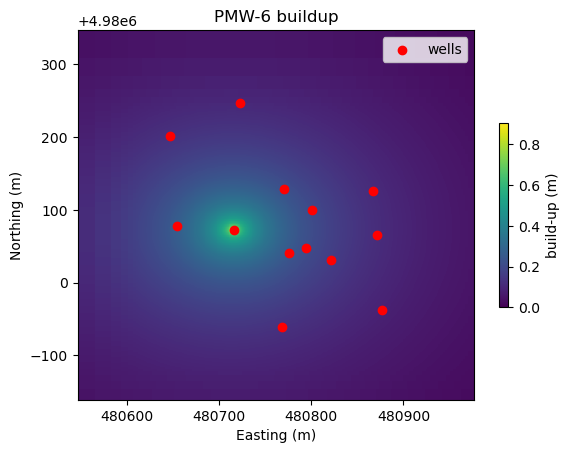

In [225]:
#plotting
fig, ax = plt.subplots()
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
cb = pmv.plot_array(
    drawdown[-1]
)

plt.colorbar(cb, shrink=0.5, label="build-up (m)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
#plotting wells on top of the buildup field
wells_e = [coords['Easting'] for coords in wells.values()]
wells_n = [coords['Northing'] for coords in wells.values()]
plt.scatter(wells_e, wells_n, marker="o", color="red", label="wells")
plt.legend()
plt.xlim(min(wells_e) - 100, max(wells_e) + 100)
plt.ylim(min(wells_n) - 100, max(wells_n) + 100)
plt.title(f"{injection_tests[inj_ID]['inj_well']} buildup")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  
#plt.savefig(f"{ws}/Figs/map/{injection_tests[inj_ID]["inj_well"]}_sim_buildup.png")


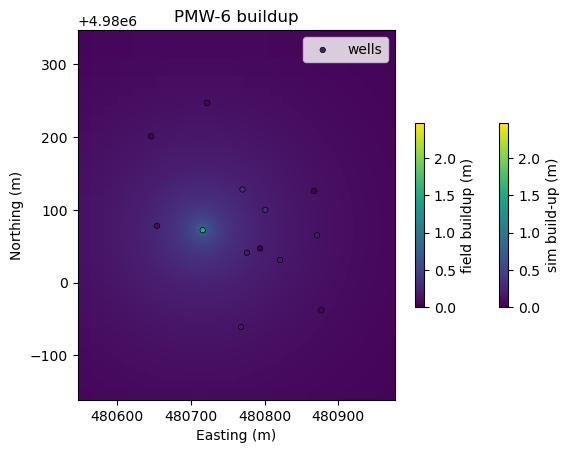

In [226]:
#plotting field vs sim

wells_e = [coords['Easting'] for coords in wells.values()]
wells_n = [coords['Northing'] for coords in wells.values()]
wells_buildup = [coords[injection_tests[inj_ID]["inj_well"] + ' max buildup'] for coords in wells.values()]
vmin = min(np.min(drawdown[-1]), np.min(wells_buildup))
vmax = max(np.max(drawdown[-1]), np.max(wells_buildup))
fig, ax = plt.subplots()
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
cb = pmv.plot_array(
    drawdown[-1], vmin=vmin, vmax=vmax
)

plt.colorbar(cb, shrink=0.5, label="sim build-up (m)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
#plotting wells on top of the buildup field

plt.scatter(wells_e, wells_n, c=wells_buildup, cmap='viridis',
            marker="o", edgecolor='black', linewidth=0.5, 
            label="wells", s=15,
            vmin=vmin, vmax=vmax
            )
plt.colorbar(label="field buildup (m)", shrink=0.5)
plt.legend()
plt.xlim(min(wells_e) - 100, max(wells_e) + 100)
plt.ylim(min(wells_n) - 100, max(wells_n) + 100)
plt.title(f"{injection_tests[inj_ID]['inj_well']} buildup")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  
#plt.savefig(f"{ws}/Figs/map/{injection_tests[inj_ID]["inj_well"]}_field_sim_buildup.png")



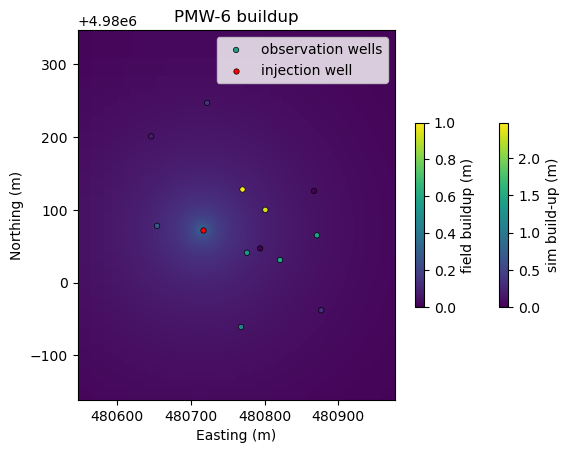

In [227]:
#plotting field vs sim v2
wells_e = [coords['Easting'] for key, coords in wells.items() if key != injection_tests[inj_ID]["inj_well"]]
wells_n = [coords['Northing'] for key, coords in wells.items() if key != injection_tests[inj_ID]["inj_well"]]
wells_buildup = [coords[injection_tests[inj_ID]["inj_well"] + ' max buildup'] 
                 for key, coords in wells.items() if key != injection_tests[inj_ID]["inj_well"]]
wells_e_inj = [coords['Easting'] for key, coords in wells.items() if key == injection_tests[inj_ID]["inj_well"]]
wells_n_inj = [coords['Northing'] for key, coords in wells.items() if key == injection_tests[inj_ID]["inj_well"]]
#vmax = np.max(wells_buildup)
fig, ax = plt.subplots()
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
cb = pmv.plot_array(
    drawdown[-1], vmin=vmin, vmax=vmax
)

plt.colorbar(cb, shrink=0.5, label="sim build-up (m)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
#plotting wells on top of the buildup field

plt.scatter(wells_e, wells_n, c=wells_buildup, cmap='viridis',
            marker="o", edgecolor='black', linewidth=0.5, 
            label="observation wells", s=15,
            )
plt.scatter(wells_e_inj, wells_n_inj, color='red',
            marker="o", edgecolor='black', linewidth=0.5, 
            label="injection well", s=15,
            )
plt.colorbar(label="field buildup (m)", shrink=0.5)
plt.legend()
plt.xlim(min(wells_e) - 100, max(wells_e) + 100)
plt.ylim(min(wells_n) - 100, max(wells_n) + 100)
plt.title(f"{injection_tests[inj_ID]['inj_well']} buildup")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  
#plt.savefig(f"{ws}/Figs/map/{injection_tests[inj_ID]["inj_well"]}_field_sim_buildup_v2.png")

C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_29092\364157822.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  field_data_plot['elapsed'] = field_df[field_df["well"] == well_plot]['elapsed'].str.replace(',','').astype(float)
C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_29092\364157822.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  field_data_plot['elapsed'] = field_df[field_df["well"] == well_plot]['elapsed'].str.replace(',','').astype(float)
C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_29092

'\n    time = time_series[:, 0] * 1440*60 #converting the simulated data from day to minutes\n    #rad = 0.2\n\n    def theis_drawdown(Q, T, r, S, t):\n        u = r ** 2 * S / 4. / T / t\n        wu = scipy.special.exp1(u)\n        s = Q / 4. / np.pi / T * wu\n        return s\n\n    rad = (\n        (wells[injection_tests[inj_ID]["inj_well"]]["Easting"] - wells[well_plot][\'Easting\']) ** 2 + \n        (wells[injection_tests[inj_ID]["inj_well"]][\'Northing\'] - wells[well_plot][\'Northing\']) ** 2\n        ) ** 0.5\n    #rad = 0.2\n    theis = theis_drawdown(Q=injection_tests[inj_ID]["inj_rate"], T=transmissivity, r=rad, S=storage_coefficient, t=time) #time in day for the Theis solution, units consistency\n\n\n    plt.plot(\n        time, \n        theis*-1., \n        label="Theis",\n    )\n'

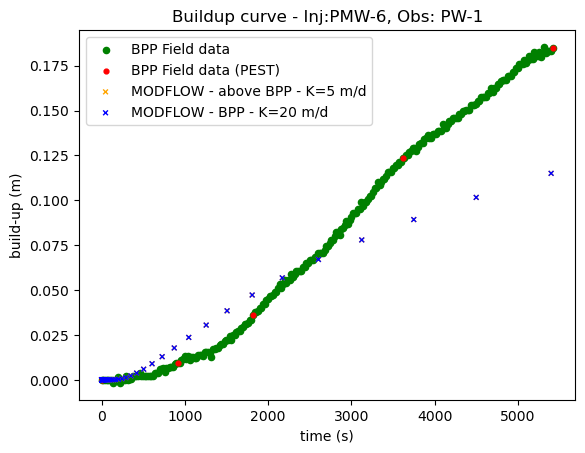

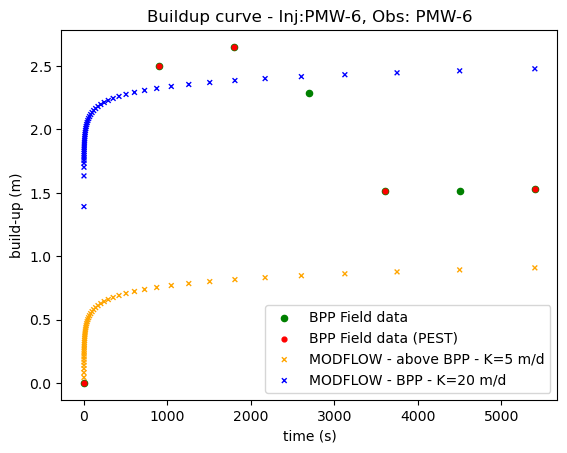

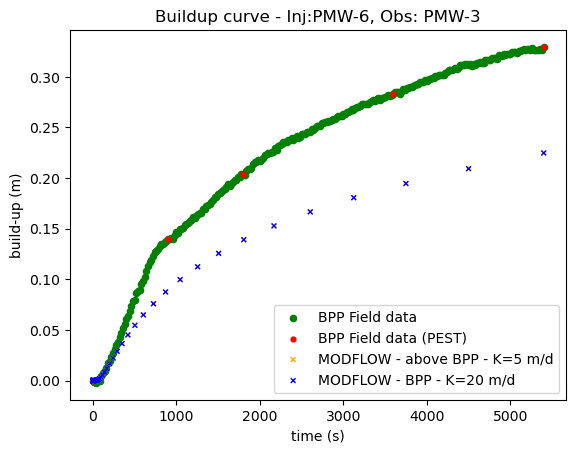

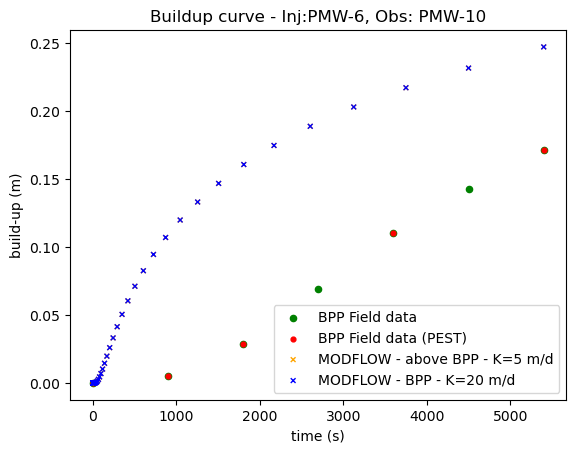

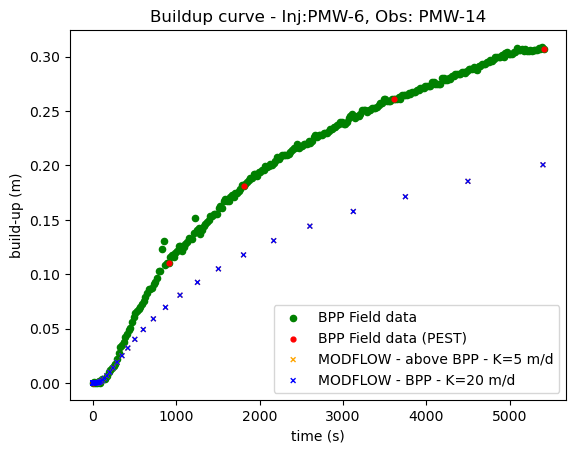

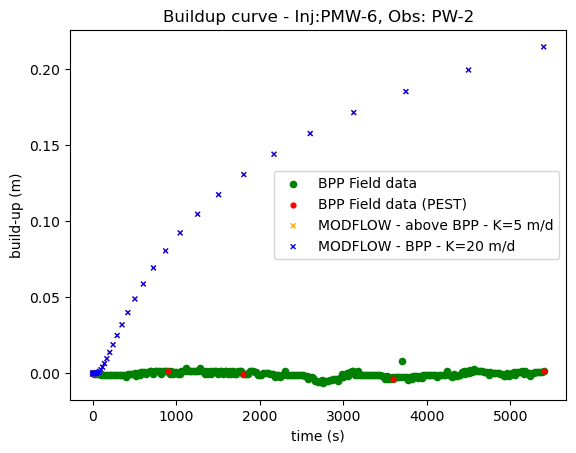

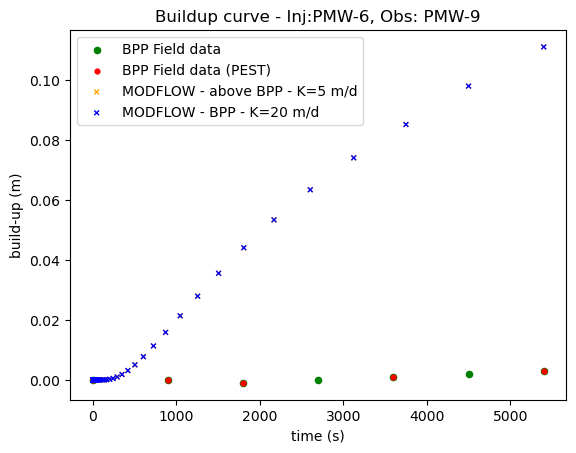

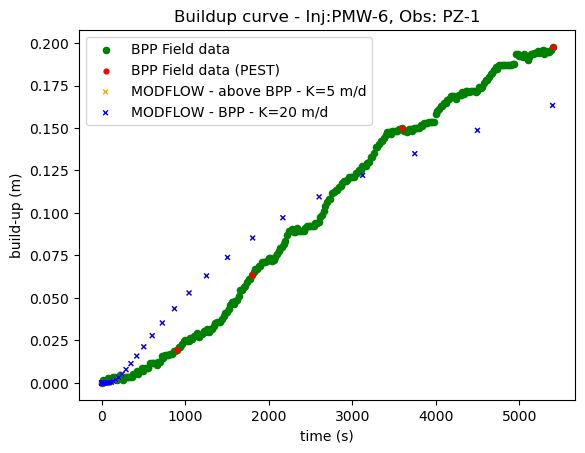

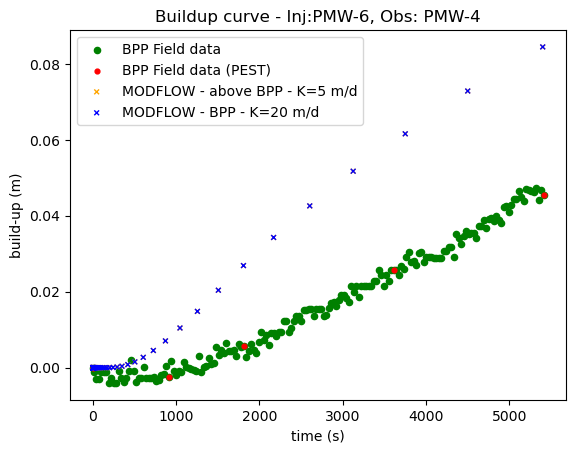

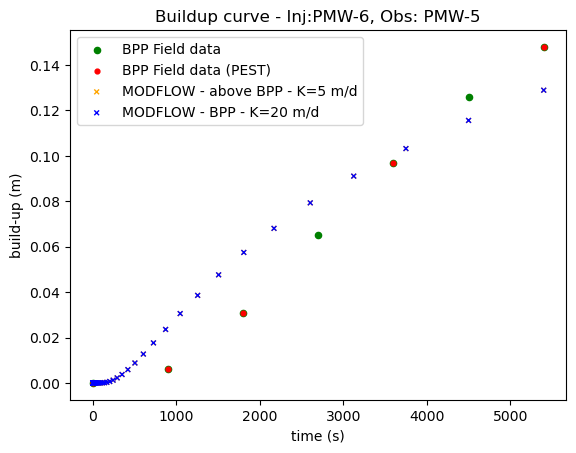

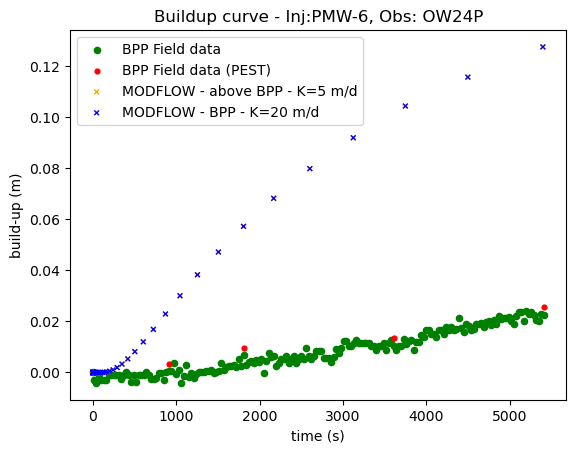

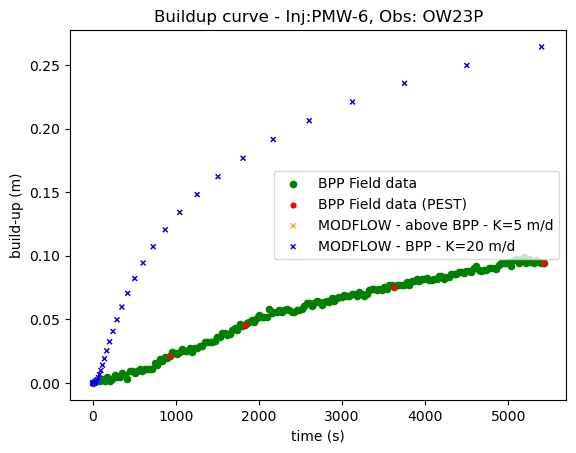

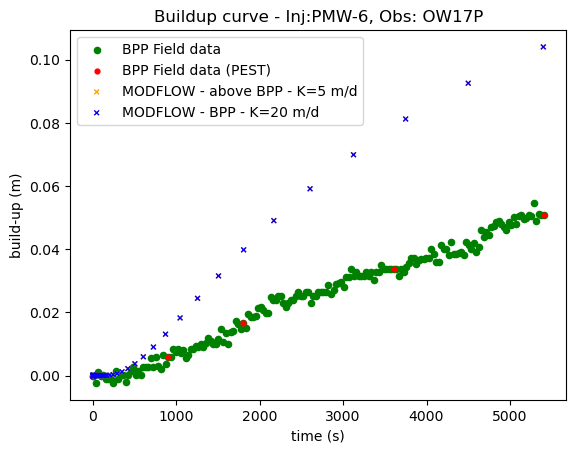

In [238]:
# Closer look at PW-1
#transmissivity = abs(botm_dis[layer]) * hk[layer] #calculating T for the layer of interest for Theis solution plot
for well_plot in wells: 
    if well_plot == injection_tests[inj_ID]["inj_well"]:
        field_df = pd.read_csv(f'../data/full_field_data/{injection_tests[inj_ID]["inj_well"]}_field_inj.csv')
        pest_df = pd.read_csv(f'../data/backup_injection_loc_observation/{injection_tests[inj_ID]["inj_well"]}_inj.csv')
    else: 
        field_df = pd.read_csv(f'../data/full_field_data/{injection_tests[inj_ID]["inj_well"]}_field.csv')
        pest_df = pd.read_csv(f'../data/{injection_tests[inj_ID]["inj_well"]}.csv')
    fig, ax = plt.subplots()

    # plot MODFLOW results for each obs well

    #field curve
    field_data_plot = field_df[field_df["well"] == well_plot]
    try:
        field_data_plot['elapsed'] = field_df[field_df["well"] == well_plot]['elapsed'].str.replace(',','').astype(float)
    except AttributeError:
        pass
    plt.scatter(field_data_plot['elapsed'], field_data_plot['buildup(m)'], 
                label="BPP Field data", s=20, marker="o", color="green")
    
    pest_df['elapsed'] = pd.to_timedelta(pest_df['elapsed']).dt.total_seconds()
    pest_df_plot = pest_df[pest_df["well"] == well_plot]
    plt.scatter(pest_df_plot['elapsed'], pest_df_plot['buildup(m)'], 
                label="BPP Field data (PEST)", s=12, 
                marker="o", color="red")


    #plotting data above BPP
    idx = []
    i, j = model_grid.intersect(wells[well_plot]['Easting'], wells[well_plot]['Northing'])
    idx.append((0, i, j)) 
    time_series = head_obj.get_ts(idx)
    t = top[i, j]
    ax.scatter(
        time_series[:, 0] * 1440*60, 
        time_series[:, 1] -t, 
        ls="", 
        marker="x", 
        color='orange',
        label=f"MODFLOW - above BPP - K={hk[0]} m/d",
        s=12
    )

    #simulation curve FOR BPP
    idx = []
    i, j = model_grid.intersect(wells[well_plot]['Easting'], wells[well_plot]['Northing'])
    idx.append((1, i, j)) 
    time_series = head_obj.get_ts(idx)
    t = top[i, j]
    ax.scatter(
        time_series[:, 0] * 1440*60, 
        time_series[:, 1] -t, 
        ls="", 
        marker="x", 
        color='blue',
        label=f"MODFLOW - BPP - K={hk[1]} m/d",
        s=12
    )

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(f"build-up (m)")

    ax.legend()
    plt.title(f"Buildup curve - Inj:{injection_tests[inj_ID]["inj_well"]}, Obs: {well_plot}")

    #plt.savefig(f"{ws}/Figs/curve/inj-{injection_tests[inj_ID]["inj_well"]}_obs-{well_plot}_loglinear.png")
'''
# Linear-linear scale
    fig1, ax1 = plt.subplots()
    ax1.plot(time_series[:, 0] * 1440*60, time_series[:, 1] - t, ls="", marker="x", markerfacecolor="none", markeredgecolor="blue", label=f"MODFLOW - K={hk[0]}")
    ax1.scatter(field_data_plot['elapsed'], field_data_plot['buildup(m)'], label="Field data", s=20, marker="o", color="green")
    ax1.scatter(pest_df_plot['elapsed'], pest_df_plot['buildup(m)'], label="Field data used in the PEST inversion", s=12, marker="o", color="red")
    ax1.set_xlabel("time (s)")
    ax1.set_ylabel(f"build-up (m)")
    ax1.legend()
    ax1.set_title(f"Buildup curve - Inj:{injection_tests[inj_ID]['inj_well']}, Obs: {well_plot}")
    plt.savefig(f"{ws}/Figs/curve/inj-{injection_tests[inj_ID]["inj_well"]}_obs-{well_plot}_linear.png")

    # Log-log scale
    fig2, ax2 = plt.subplots()
    ax2.plot(time_series[:, 0] * 1440*60, time_series[:, 1] - t, ls="", marker="x", markerfacecolor="none", markeredgecolor="blue", label=f"MODFLOW - K={hk[0]}")
    ax2.scatter(field_data_plot['elapsed'], field_data_plot['buildup(m)'], label="Field data", s=20, marker="o", color="green")
    ax2.scatter(pest_df_plot['elapsed'], pest_df_plot['buildup(m)'], label="Field data used in the PEST inversion", s=12, marker="o", color="red")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("time (s)")
    ax2.set_ylabel(f"build-up (m)")
    ax2.legend()
    ax2.set_title(f"Buildup curve - Inj:{injection_tests[inj_ID]['inj_well']}, Obs: {well_plot}")
    plt.savefig(f"{ws}/Figs/curve/inj-{injection_tests[inj_ID]["inj_well"]}_obs-{well_plot}_loglog.png")

    plt.show()
'''
'''
    time = time_series[:, 0] * 1440*60 #converting the simulated data from day to minutes
    #rad = 0.2

    def theis_drawdown(Q, T, r, S, t):
        u = r ** 2 * S / 4. / T / t
        wu = scipy.special.exp1(u)
        s = Q / 4. / np.pi / T * wu
        return s

    rad = (
        (wells[injection_tests[inj_ID]["inj_well"]]["Easting"] - wells[well_plot]['Easting']) ** 2 + 
        (wells[injection_tests[inj_ID]["inj_well"]]['Northing'] - wells[well_plot]['Northing']) ** 2
        ) ** 0.5
    #rad = 0.2
    theis = theis_drawdown(Q=injection_tests[inj_ID]["inj_rate"], T=transmissivity, r=rad, S=storage_coefficient, t=time) #time in day for the Theis solution, units consistency


    plt.plot(
        time, 
        theis*-1., 
        label="Theis",
    )
'''
    